# Pemetaan Lahan Sawah dan Non-Sawah dari Citra Sentinel-2

Notebook ini memandu proses klasifikasi tutupan lahan dari data sampel hingga peta hasil. Penjelasan ditulis per tahap agar arti data, metode, dan hasilnya lebih mudah diikuti.

**Hasil akhir:** peta kelas Sawah/Non-Sawah, evaluasi model, dan GeoTIFF hasil klasifikasi.

## Alur singkat

1. Membaca dan memeriksa poligon sampel Sawah dan Non-Sawah.
2. Menentukan area kajian dan mengunduh komposit Sentinel-2.
3. Meninjau citra serta mengekstrak nilai spektral dari setiap poligon.
4. Melatih Random Forest dan mengevaluasi prediksinya.
5. Mengklasifikasikan piksel citra dan menyimpan peta.

> Jalankan sel dari atas ke bawah. Jika GeoTIFF yang sesuai sudah ada, notebook akan menggunakannya kembali. Jika belum ada, sel unduh akan meminta autentikasi Copernicus melalui browser dan memerlukan koneksi internet.

## 1. Persiapan lingkungan dan lokasi berkas

Notebook mencari arsip `SAWAH.zip` dan `Non_SAWAH.zip` dari folder proyek atau folder induknya. Hasil citra, peta, dan visualisasi disimpan di `Tugas/polutan/`.

Pastikan seluruh pustaka pada `requirements.txt` sudah terpasang sebelum menjalankan notebook.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.mask import mask
from shapely.geometry import box
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "SAWAH.zip").is_file()
        and (candidate / "Non_SAWAH.zip").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Arsip SAWAH.zip dan Non_SAWAH.zip tidak ditemukan. "
        "Simpan keduanya di folder proyek."
    )

RESULT_DIR = PROJECT_ROOT / "Tugas" / "polutan"
if not RESULT_DIR.is_dir():
    raise FileNotFoundError(f"Folder hasil tidak ditemukan: {RESULT_DIR}")

SAWAH_PATH = PROJECT_ROOT / "SAWAH.zip"
NON_SAWAH_PATH = PROJECT_ROOT / "Non_SAWAH.zip"
RASTER_NAME = "sentinel2_sawah_nonsawah.tif"
RASTER_CANDIDATES = [RESULT_DIR / RASTER_NAME, PROJECT_ROOT / RASTER_NAME]
OUTPUT_PATH = next(
    (candidate for candidate in RASTER_CANDIDATES if candidate.is_file()),
    RESULT_DIR / RASTER_NAME,
)

print(f"Folder proyek : {PROJECT_ROOT}")
print(f"Folder hasil  : {RESULT_DIR}")
print(f"Citra Sentinel-2: {OUTPUT_PATH}")
print(f"Arsip sampel tersedia: {SAWAH_PATH.is_file()} dan {NON_SAWAH_PATH.is_file()}")

Folder proyek : D:\SEMESTER 5\PSD\TUGAS
Folder hasil  : D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan
Citra Sentinel-2: D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\sentinel2_sawah_nonsawah.tif
Arsip sampel tersedia: True dan True


## 2. Memeriksa data sampel (ground truth)

Ground truth adalah contoh lokasi yang kelasnya sudah diketahui. Pada notebook ini, setiap poligon dari `SAWAH.zip` diberi label **Sawah (1)** dan setiap poligon dari `Non_SAWAH.zip` diberi label **Non-Sawah (0)**.

Poligon harus memiliki sistem koordinat (CRS) dan geometri yang valid. Semua geometri diseragamkan ke EPSG:4326 untuk menentukan area permintaan citra. Perbaikan hanya diterapkan pada geometri yang ditandai tidak valid.

In [2]:
def load_samples(path, class_name, class_id):
    if not path.is_file():
        raise FileNotFoundError(f"Arsip sampel tidak ditemukan: {path}")

    samples = gpd.read_file(path)
    if samples.empty:
        raise ValueError(f"Arsip tidak memiliki fitur: {path.name}")
    if samples.crs is None:
        raise ValueError(f"CRS tidak diketahui pada {path.name}.")
    if samples.geometry.isna().any() or samples.geometry.is_empty.any():
        raise ValueError(f"Ada geometri kosong pada {path.name}.")

    samples = samples.to_crs("EPSG:4326")
    invalid = ~samples.geometry.is_valid
    if invalid.any():
        print(f"Memperbaiki {int(invalid.sum())} geometri di {path.name}.")
        samples.loc[invalid, "geometry"] = samples.loc[invalid].geometry.make_valid()
    if (~samples.geometry.is_valid).any():
        raise ValueError(f"Masih ada geometri tidak valid pada {path.name}.")

    samples["kelas"] = class_name
    samples["label"] = class_id
    return samples


gdf_sawah = load_samples(SAWAH_PATH, "Sawah", 1)
gdf_nonsawah = load_samples(NON_SAWAH_PATH, "Non-Sawah", 0)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_nonsawah, gdf_sawah], ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326",
)

jumlah_per_kelas = (
    gdf_gabungan.groupby(["label", "kelas"])
    .size()
    .rename("Jumlah poligon")
    .reset_index()
)
print(f"Jumlah seluruh sampel: {len(gdf_gabungan)} poligon")
display(jumlah_per_kelas)
display(gdf_gabungan[["FID", "kelas", "label"]].head(8))

Memperbaiki 1 geometri di SAWAH.zip.


Jumlah seluruh sampel: 100 poligon


,label,kelas,Jumlah poligon
0,0,Non-Sawah,50
1,1,Sawah,50


,FID,kelas,label
0,0,Non-Sawah,0
1,1,Non-Sawah,0
2,2,Non-Sawah,0
3,3,Non-Sawah,0
4,4,Non-Sawah,0
5,5,Non-Sawah,0
6,6,Non-Sawah,0
7,7,Non-Sawah,0


### Sebaran dan keseimbangan sampel

Grafik kiri menunjukkan jumlah poligon per kelas. Peta kanan memperlihatkan lokasi poligon yang akan menjadi contoh pelatihan dan pengujian. Peta ini adalah sebaran **sampel**, bukan peta tutupan lahan hasil klasifikasi.

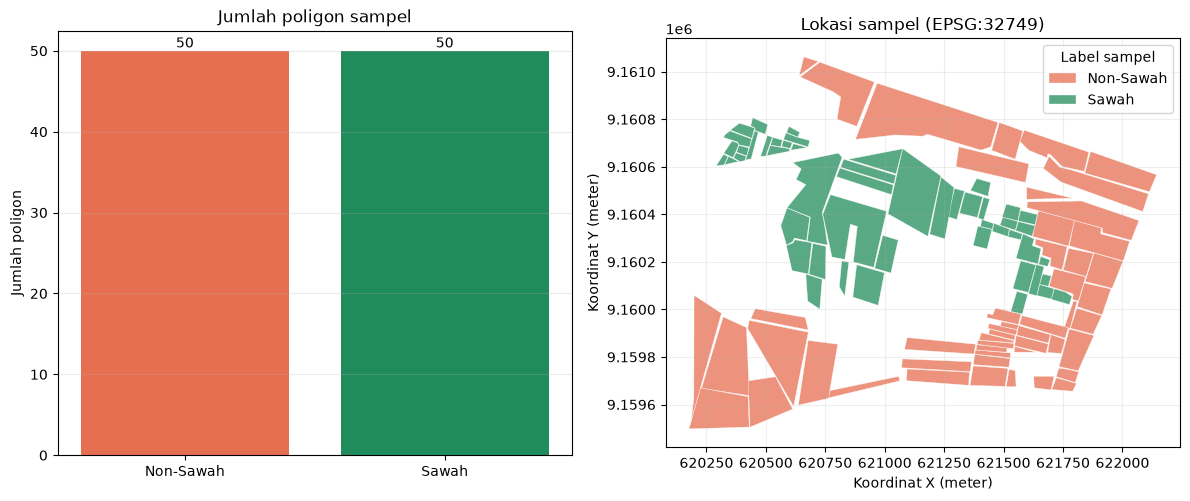

In [3]:
CLASS_COLORS = {"Non-Sawah": "#e76f51", "Sawah": "#218c5b"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = gdf_gabungan["kelas"].value_counts().reindex(
    ["Non-Sawah", "Sawah"], fill_value=0
)
axes[0].bar(
    counts.index,
    counts.values,
    color=[CLASS_COLORS[name] for name in counts.index],
)
axes[0].set_title("Jumlah poligon sampel")
axes[0].set_ylabel("Jumlah poligon")
axes[0].grid(axis="y", alpha=0.25)
for index, count in enumerate(counts.values):
    axes[0].text(index, count, str(count), ha="center", va="bottom")

samples_utm = gdf_gabungan.to_crs("EPSG:32749")
for class_name, color in CLASS_COLORS.items():
    samples_utm[samples_utm["kelas"] == class_name].plot(
        ax=axes[1],
        color=color,
        edgecolor="white",
        linewidth=0.35,
        alpha=0.75,
        label=class_name,
    )
axes[1].set_title("Lokasi sampel (EPSG:32749)")
axes[1].set_xlabel("Koordinat X (meter)")
axes[1].set_ylabel("Koordinat Y (meter)")
axes[1].set_aspect("equal")
axes[1].legend(title="Label sampel")
axes[1].grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 3. Menetapkan area kajian

openEO menerima batas area dalam koordinat geografis. Agar buffer benar-benar berukuran **500 meter**, batas sampel terlebih dahulu dihitung dalam EPSG:32749 (UTM zona 49S), lalu dibuat kotak pembatas dengan tambahan 500 meter di setiap sisi.

Kotak ini mencakup seluruh sampel dan area sekitarnya; bentuknya bukan hasil buffer individual setiap poligon.

,Batas area,Koordinat (EPSG:4326)
0,Barat,112.084868
1,Selatan,-7.607009
2,Timur,112.111821
3,Utara,-7.583746


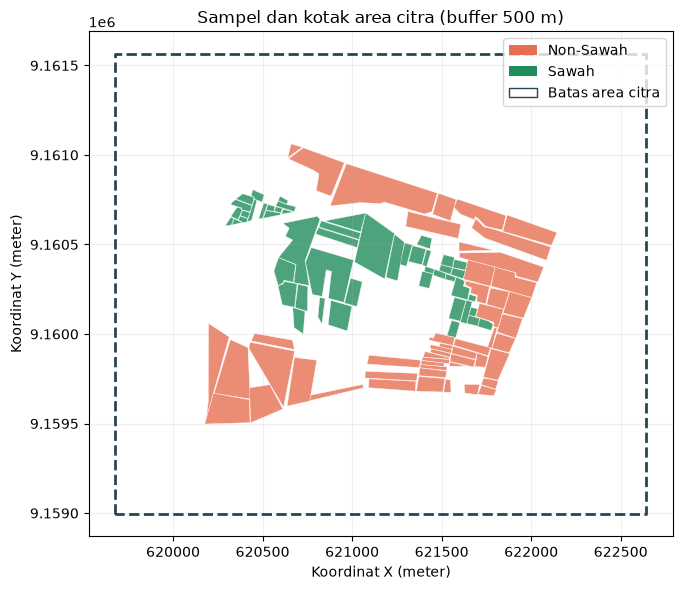

In [4]:
samples_utm = gdf_gabungan.to_crs("EPSG:32749")
min_x, min_y, max_x, max_y = samples_utm.total_bounds
buffer_m = 500

extent_utm = box(
    min_x - buffer_m,
    min_y - buffer_m,
    max_x + buffer_m,
    max_y + buffer_m,
)
extent_wgs84 = (
    gpd.GeoSeries([extent_utm], crs="EPSG:32749")
    .to_crs("EPSG:4326")
    .iloc[0]
)
west, south, east, north = extent_wgs84.bounds
bbox = {
    "west": float(west),
    "south": float(south),
    "east": float(east),
    "north": float(north),
}

display(
    pd.DataFrame(
        {
            "Batas area": ["Barat", "Selatan", "Timur", "Utara"],
            "Koordinat (EPSG:4326)": [west, south, east, north],
        }
    ).round(6)
)

fig, ax = plt.subplots(figsize=(8, 6))
for class_name, color in CLASS_COLORS.items():
    samples_utm[samples_utm["kelas"] == class_name].plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.35,
        alpha=0.8,
    )
gpd.GeoSeries([extent_utm], crs="EPSG:32749").boundary.plot(
    ax=ax, color="#264653", linewidth=2, linestyle="--"
)
ax.set_title("Sampel dan kotak area citra (buffer 500 m)")
ax.set_xlabel("Koordinat X (meter)")
ax.set_ylabel("Koordinat Y (meter)")
ax.set_aspect("equal")
ax.legend(
    handles=[
        Patch(facecolor=CLASS_COLORS[name], label=name)
        for name in ("Non-Sawah", "Sawah")
    ]
    + [Patch(facecolor="none", edgecolor="#264653", label="Batas area citra")],
    loc="best",
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 4. Mengambil komposit Sentinel-2 L2A

Permintaan citra memakai rentang **1 Mei–30 September 2026**, dengan awan maksimum **10%**. Komposit median waktu merangkum pengamatan yang tersedia selama rentang tanggal tersebut menjadi satu nilai per piksel.

| Band | Panjang gelombang / kegunaan umum |
|---|---|
| B02 | Biru; membantu membedakan air dan permukaan |
| B03 | Hijau; tampilan warna alami |
| B04 | Merah; tampilan warna alami dan indeks vegetasi |
| B08 | Inframerah dekat; peka terhadap vegetasi |
| B11 | Inframerah gelombang pendek; peka terhadap kelembapan dan permukaan terbangun |

Jika berkas GeoTIFF sudah ada, proses autentikasi dan unduhan dilewati. Jika belum, notebook mengirim permintaan ke Copernicus melalui openEO.

In [5]:
if OUTPUT_PATH.is_file():
    print(f"Menggunakan citra yang sudah tersedia: {OUTPUT_PATH}")
else:
    import openeo

    connection = openeo.connect(
        "openeo.dataspace.copernicus.eu"
    ).authenticate_oidc()
    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=["2026-05-01", "2026-09-30"],
        bands=["B02", "B03", "B04", "B08", "B11"],
        max_cloud_cover=10,
    )
    composite_s2 = datacube.median_time()
    print(f"Mengunduh citra ke: {OUTPUT_PATH}")
    composite_s2.download(str(OUTPUT_PATH), format="GTiff")
    if not OUTPUT_PATH.is_file():
        raise FileNotFoundError(f"Unduhan tidak menghasilkan berkas: {OUTPUT_PATH}")
    print("Unduhan citra selesai.")

Menggunakan citra yang sudah tersedia: D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\sentinel2_sawah_nonsawah.tif


## 5. Memeriksa citra dan melihat warna alami

Sebelum melatih model, periksa ukuran, CRS, band, dan nilai nodata citra. Pratinjau berikut menyusun **B04 (merah), B03 (hijau), dan B02 (biru)** menjadi komposit warna alami. Kontras diregangkan dengan persentil 2–98 hanya untuk tampilan; nilai raster untuk klasifikasi tidak diubah oleh peregangan ini.

Garis berwarna menunjukkan batas poligon sampel di atas citra.

,Properti,Nilai
0,Lebar × tinggi,299 × 259
1,Jumlah band,5
2,Resolusi piksel (meter),10 × 10
3,CRS,EPSG:32749
4,Nilai nodata,-32768.0
5,Nama band,"B02, B03, B04, B08, B11"


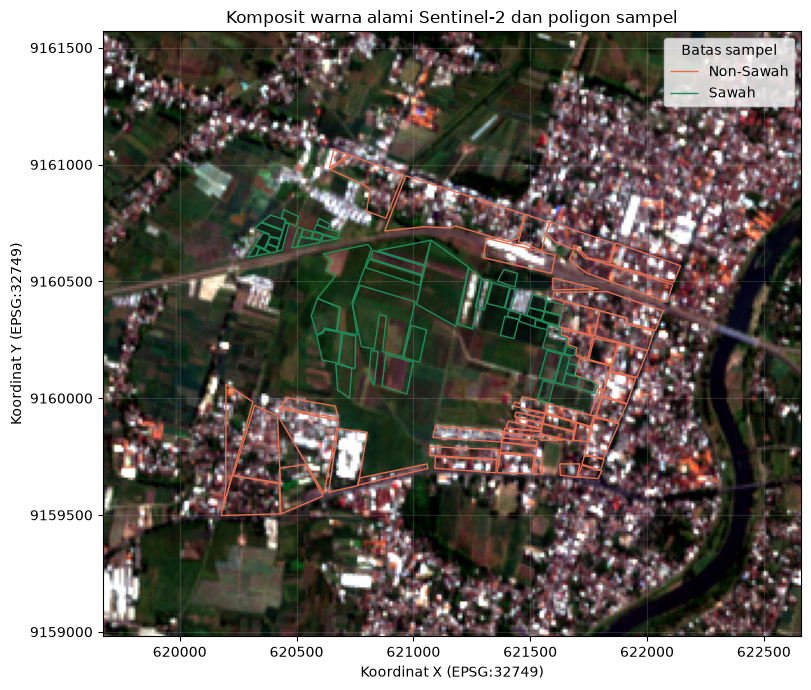

In [6]:
BAND_NAMES = ["B02", "B03", "B04", "B08", "B11"]

with rasterio.open(OUTPUT_PATH) as src:
    if src.count != len(BAND_NAMES):
        raise ValueError(
            f"Citra harus memiliki {len(BAND_NAMES)} band; ditemukan {src.count}."
        )
    if src.crs is None:
        raise ValueError("CRS citra tidak diketahui.")

    raster_crs = src.crs
    raster_bounds = src.bounds
    rgb_bands = src.read([3, 2, 1], masked=True).astype(np.float32).filled(np.nan)
    raster_valid_rgb = np.isfinite(rgb_bands).all(axis=0)
    if not raster_valid_rgb.any():
        raise ValueError("Citra tidak memiliki piksel valid untuk pratinjau.")

    rgb = np.zeros((*raster_valid_rgb.shape, 3), dtype=np.float32)
    for channel in range(3):
        values = rgb_bands[channel][raster_valid_rgb]
        low, high = np.nanpercentile(values, [2, 98])
        if high <= low:
            high = low + 1
        rgb[:, :, channel] = np.clip(
            (rgb_bands[channel] - low) / (high - low), 0, 1
        )
    rgb[~raster_valid_rgb] = 1

    raster_info = pd.DataFrame(
        {
            "Properti": [
                "Lebar × tinggi",
                "Jumlah band",
                "Resolusi piksel (meter)",
                "CRS",
                "Nilai nodata",
                "Nama band",
            ],
            "Nilai": [
                f"{src.width} × {src.height}",
                src.count,
                f"{abs(src.res[0]):g} × {abs(src.res[1]):g}",
                str(src.crs),
                src.nodata,
                ", ".join(BAND_NAMES),
            ],
        }
    )
    raster_extent = (
        raster_bounds.left,
        raster_bounds.right,
        raster_bounds.bottom,
        raster_bounds.top,
    )

display(raster_info)
samples_in_raster_crs = gdf_gabungan.to_crs(raster_crs)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(rgb, extent=raster_extent, origin="upper")
for class_name, color in CLASS_COLORS.items():
    samples_in_raster_crs[samples_in_raster_crs["kelas"] == class_name].boundary.plot(
        ax=ax, color=color, linewidth=1, label=class_name
    )
ax.set_title("Komposit warna alami Sentinel-2 dan poligon sampel")
ax.set_xlabel(f"Koordinat X ({raster_crs})")
ax.set_ylabel(f"Koordinat Y ({raster_crs})")
ax.ticklabel_format(style="plain", useOffset=False)
ax.legend(title="Batas sampel")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 6. Membentuk fitur spektral untuk setiap sampel

Nilai rata-rata lima band di dalam setiap poligon menjadi fitur dasar. Empat indeks ditambahkan untuk menyoroti karakteristik yang berbeda.

| Fitur | Rumus | Interpretasi umum |
|---|---|---|
| NDVI | (B08 − B04) / (B08 + B04) | Respons vegetasi |
| NDMI | (B08 − B11) / (B08 + B11) | Kelembapan vegetasi/permukaan |
| NDBI | (B11 − B08) / (B11 + B08) | Permukaan terbangun |
| MNDWI | (B03 − B11) / (B03 + B11) | Air terbuka |

Indeks dihitung per piksel lebih dahulu, lalu dirata-ratakan dalam poligon. Cara ini menjaga informasi yang masih tampak pada piksel-piksel di dalam satu sampel. Semua indeks berada pada rentang kurang lebih −1 sampai 1; penyebut nol ditangani agar hasil tetap terdefinisi.

In [7]:
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDMI", "NDBI", "MNDWI"]
LABEL_NAMES = ["Non-Sawah", "Sawah"]


def normalized_difference(first, second):
    denominator = first + second
    return np.divide(
        first - second,
        denominator,
        out=np.zeros_like(first, dtype=np.float32),
        where=np.abs(denominator) > 1e-6,
    )


def make_feature_stack(bands):
    bands = np.asarray(bands, dtype=np.float32)
    blue, green, red, nir, swir = bands
    return np.vstack(
        (
            bands,
            normalized_difference(nir, red),
            normalized_difference(nir, swir),
            normalized_difference(swir, nir),
            normalized_difference(green, swir),
        )
    )


features, labels, sample_ids = [], [], []
with rasterio.open(OUTPUT_PATH) as src:
    for _, sample in samples_in_raster_crs.iterrows():
        geometry = sample.geometry
        if not geometry.is_valid:
            geometry = geometry.make_valid()
        clipped, _ = mask(
            src, [geometry.__geo_interface__], crop=True, filled=False
        )
        pixel_bands = np.ma.asarray(clipped, dtype=np.float32).filled(np.nan)
        valid_pixels = np.isfinite(pixel_bands).all(axis=0)
        if not valid_pixels.any():
            raise ValueError(
                f"Poligon FID={sample['FID']} tidak menutupi piksel citra yang valid. "
                "Periksa kembali area unduhan dan posisi sampel."
            )

        per_pixel_features = make_feature_stack(pixel_bands[:, valid_pixels])
        features.append(per_pixel_features.mean(axis=1))
        labels.append(int(sample["label"]))
        sample_ids.append(sample["FID"])

X = np.asarray(features, dtype=np.float32)
y = np.asarray(labels, dtype=np.uint8)
if not np.isfinite(X).all():
    raise ValueError("Fitur berisi nilai tak hingga atau NaN; periksa citra dan sampel.")
if len(np.unique(y)) != 2:
    raise ValueError("Kedua kelas Sawah dan Non-Sawah harus tersedia.")

feature_table = pd.DataFrame(X, columns=FEATURE_NAMES)
feature_table.insert(0, "kelas", [LABEL_NAMES[label] for label in y])
feature_table.insert(0, "FID", sample_ids)
print(f"Matriks fitur: {X.shape[0]} sampel × {X.shape[1]} fitur")
display(feature_table.head(10).round(4))

Matriks fitur: 100 sampel × 9 fitur


,FID,kelas,B02,B03,B04,B08,B11,NDVI,NDMI,NDBI,MNDWI
0,0,Non-Sawah,1102.081421,1217.081421,1284.903687,1904.889038,2364.636963,0.1966,-0.1073,0.1073,-0.3221
1,1,Non-Sawah,832.500000,970.181030,1094.663818,1933.784424,2292.068848,0.2787,-0.0889,0.0889,-0.4116
2,2,Non-Sawah,955.503601,1080.071899,1191.374146,2001.251831,2375.906494,0.2598,-0.0901,0.0901,-0.3878
3,3,Non-Sawah,1036.565186,1168.452148,1258.860840,2046.478149,2508.252197,0.2475,-0.1057,0.1057,-0.3804
4,4,Non-Sawah,925.559998,1087.520020,1293.880005,2026.719971,2451.479980,0.2200,-0.0955,0.0955,-0.3815
5,5,Non-Sawah,797.916687,951.500000,1040.099976,2129.050049,2288.449951,0.3324,-0.0456,0.0456,-0.4149
6,6,Non-Sawah,759.607117,884.857117,1018.678589,1902.678589,2311.142822,0.3022,-0.0989,0.0989,-0.4471
7,7,Non-Sawah,958.269226,1077.538452,1232.192261,1878.153809,2448.384521,0.2069,-0.1357,0.1357,-0.3926
8,8,Non-Sawah,852.517212,972.758606,1124.517212,1826.931030,2366.172363,0.2427,-0.1304,0.1304,-0.4255
9,9,Non-Sawah,748.032288,894.225830,984.419373,2043.032227,2443.161377,0.3469,-0.0876,0.0876,-0.4615


### Cara membaca tabel fitur

Setiap baris mewakili **satu poligon**, bukan satu piksel. Kolom `B02`–`B11` menyimpan rata-rata nilai reflektansi komposit di dalam poligon; kolom indeks merangkum kontras antarband. Besaran reflektansi dapat bergantung pada skala penyimpanan produk, sedangkan indeks ternormalisasi lebih mudah dibandingkan antarfitur.

In [8]:
feature_summary = (
    feature_table.groupby("kelas")[FEATURE_NAMES]
    .mean()
    .T.rename(columns={"Non-Sawah": "Rata-rata Non-Sawah", "Sawah": "Rata-rata Sawah"})
)
display(feature_summary.round(4))

kelas,Rata-rata Non-Sawah,Rata-rata Sawah
B02,903.663513,581.117004
B03,1046.970337,785.262207
B04,1138.060547,656.403381
B08,2049.132568,2793.031250
B11,2375.147461,1942.733154
NDVI,0.293300,0.616800
NDMI,-0.077600,0.175900
NDBI,0.077600,-0.175900
MNDWI,-0.400200,-0.425200


## 7. Melatih dan menguji Random Forest

Data dibagi secara **stratified**: 80% poligon untuk pelatihan dan 20% untuk pengujian, sambil mempertahankan proporsi kelas. `random_state=42` membuat pembagian dan model dapat diulang; 300 pohon digunakan untuk menggabungkan banyak aturan keputusan.

Pengujian di bawah ini memisahkan **poligon**, tetapi belum memakai pemisahan spasial berblok. Karena lokasi yang berdekatan dapat memiliki karakteristik serupa, skor pada pemisahan acak bisa lebih optimistis daripada kinerja di wilayah baru.

Jumlah sampel latih : 80
Jumlah sampel uji   : 20
Akurasi data uji    : 100.0%


,precision,recall,f1-score,support
Non-Sawah,1.0,1.0,1.0,10.0
Sawah,1.0,1.0,1.0,10.0
macro avg,1.0,1.0,1.0,20.0
weighted avg,1.0,1.0,1.0,20.0


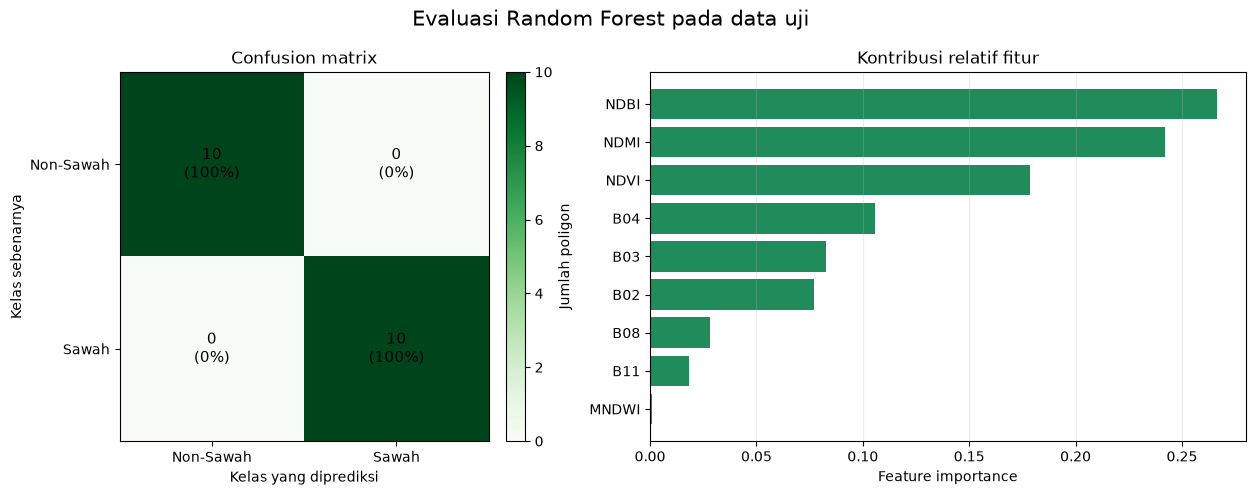

Visualisasi evaluasi disimpan: D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\evaluasi_klasifikasi_sawah_nonsawah.png


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

print(f"Jumlah sampel latih : {len(y_train)}")
print(f"Jumlah sampel uji   : {len(y_test)}")
print(f"Akurasi data uji    : {accuracy:.1%}")

metrics_table = pd.DataFrame(report).T.loc[
    LABEL_NAMES + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"],
]
display(metrics_table.round(3))

fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.35]}
)
image = axes[0].imshow(matrix, cmap="Greens")
axes[0].set(
    title="Confusion matrix",
    xlabel="Kelas yang diprediksi",
    ylabel="Kelas sebenarnya",
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
for row in range(matrix.shape[0]):
    actual_total = matrix[row].sum()
    for column in range(matrix.shape[1]):
        row_percent = 100 * matrix[row, column] / actual_total if actual_total else 0
        axes[0].text(
            column,
            row,
            f"{matrix[row, column]}\n({row_percent:.0f}%)",
            ha="center",
            va="center",
            color="black",
            fontsize=11,
        )
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label="Jumlah poligon")

importance_order = np.argsort(model.feature_importances_)
axes[1].barh(
    np.array(FEATURE_NAMES)[importance_order],
    model.feature_importances_[importance_order],
    color="#218c5b",
)
axes[1].set_title("Kontribusi relatif fitur")
axes[1].set_xlabel("Feature importance")
axes[1].grid(axis="x", alpha=0.25)
fig.suptitle("Evaluasi Random Forest pada data uji", fontsize=15)
fig.tight_layout()
EVALUATION_PATH = RESULT_DIR / "evaluasi_klasifikasi_sawah_nonsawah.png"
fig.savefig(EVALUATION_PATH, dpi=180, bbox_inches="tight")
plt.show()
print(f"Visualisasi evaluasi disimpan: {EVALUATION_PATH}")

### Menafsirkan evaluasi

- **Confusion matrix:** baris adalah kelas sebenarnya; kolom adalah prediksi. Sel diagonal berarti prediksi benar, sedangkan sel di luar diagonal menunjukkan kekeliruan.
- **Precision:** dari semua prediksi untuk suatu kelas, berapa proporsi yang benar.
- **Recall:** dari semua sampel sebenarnya pada suatu kelas, berapa proporsi yang berhasil ditemukan.
- **F1-score:** ringkasan seimbang antara precision dan recall.
- **Feature importance:** menunjukkan seberapa sering fitur membantu pemisahan dalam model; ini bukan bukti sebab-akibat dan bukan ukuran kualitas data.

Jumlah sampel uji pada pekerjaan ini terbatas. Selalu lihat jumlah `support` bersama skor, dan hindari menganggap akurasi pada sampel yang sama sebagai jaminan kinerja di tempat atau waktu lain.

## 8. Membuat peta klasifikasi seluruh citra

Setelah evaluasi, model yang telah dilatih pada seluruh data latih memprediksi setiap piksel valid pada raster. Piksel nodata dibiarkan kosong. Hasil disajikan berdampingan dengan komposit warna alami dan batas poligon sampel agar posisi, kelas, dan sumber informasi dapat dibandingkan.

Keluaran GeoTIFF menyimpan nilai **0 = Non-Sawah**, **1 = Sawah**, dan **255 = nodata**. Warna hanya untuk tampilan; nilai kelas pada berkas tetap berupa angka.

,Kelas,Piksel,Estimasi luas (ha),Proporsi (%)
0,Non-Sawah,34257,342.57,44.24
1,Sawah,43184,431.84,55.76


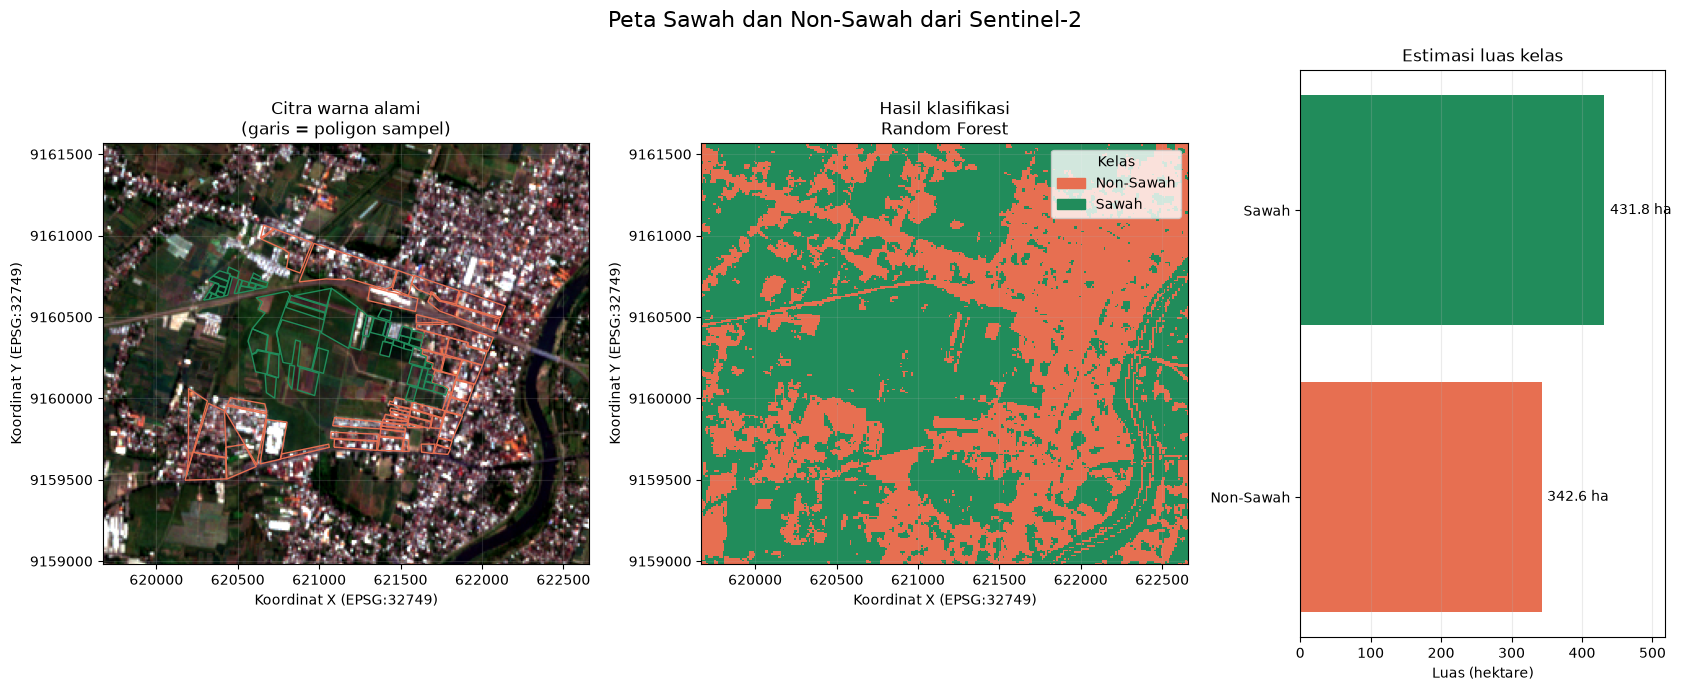

Peta klasifikasi disimpan: D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\peta_klasifikasi_sawah_nonsawah.png
GeoTIFF klasifikasi disimpan: D:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\klasifikasi_sawah_nonsawah.tif
Luas piksel valid yang dipetakan: 774.41 ha


In [10]:
CLASSIFIED_PATH = RESULT_DIR / "klasifikasi_sawah_nonsawah.tif"
MAP_PATH = RESULT_DIR / "peta_klasifikasi_sawah_nonsawah.png"
CLASS_COLORMAP = ListedColormap(
    [CLASS_COLORS["Non-Sawah"], CLASS_COLORS["Sawah"]]
)

with rasterio.open(OUTPUT_PATH) as src:
    masked_bands = src.read(masked=True)
    raster_bands = masked_bands.astype(np.float32).filled(np.nan)
    valid_map_pixels = (
        ~np.ma.getmaskarray(masked_bands).any(axis=0)
    ) & np.isfinite(raster_bands).all(axis=0)
    if not valid_map_pixels.any():
        raise ValueError("Tidak ada piksel valid untuk dipetakan.")

    map_features = make_feature_stack(raster_bands[:, valid_map_pixels]).T
    classified = np.full(valid_map_pixels.shape, 255, dtype=np.uint8)
    classified[valid_map_pixels] = model.predict(map_features).astype(np.uint8)

    output_profile = src.profile.copy()
    output_profile.update(
        count=1,
        dtype="uint8",
        nodata=255,
        compress="deflate",
    )
    with rasterio.open(CLASSIFIED_PATH, "w", **output_profile) as dst:
        dst.write(classified, 1)

    map_extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )
    pixel_area_m2 = abs(
        src.transform.a * src.transform.e - src.transform.b * src.transform.d
    )

pixel_counts = {
    class_id: int(np.count_nonzero(classified == class_id))
    for class_id in (0, 1)
}
area_table = pd.DataFrame(
    {
        "Kelas": LABEL_NAMES,
        "Piksel": [pixel_counts[0], pixel_counts[1]],
        "Estimasi luas (ha)": [
            pixel_counts[class_id] * pixel_area_m2 / 10_000
            for class_id in (0, 1)
        ],
    }
)
total_classified_area = area_table["Estimasi luas (ha)"].sum()
area_table["Proporsi (%)"] = (
    area_table["Estimasi luas (ha)"] / total_classified_area * 100
)
display(area_table.round(2))

fig, axes = plt.subplots(
    1, 3, figsize=(17, 7), gridspec_kw={"width_ratios": [1, 1, 0.75]}
)
axes[0].imshow(rgb, extent=map_extent, origin="upper")
for class_name, color in CLASS_COLORS.items():
    samples_in_raster_crs[
        samples_in_raster_crs["kelas"] == class_name
    ].boundary.plot(ax=axes[0], color=color, linewidth=1)
axes[0].set_title("Citra warna alami\n(garis = poligon sampel)")

classified_display = np.ma.masked_where(~valid_map_pixels, classified)
axes[1].imshow(
    classified_display,
    cmap=CLASS_COLORMAP,
    vmin=0,
    vmax=1,
    extent=map_extent,
    origin="upper",
    interpolation="nearest",
)
axes[1].set_title("Hasil klasifikasi\nRandom Forest")
for ax in axes[:2]:
    ax.set_xlabel(f"Koordinat X ({raster_crs})")
    ax.set_ylabel(f"Koordinat Y ({raster_crs})")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.set_aspect("equal")
    ax.grid(alpha=0.18)

axes[1].legend(
    handles=[
        Patch(color=CLASS_COLORS[name], label=name)
        for name in ("Non-Sawah", "Sawah")
    ],
    title="Kelas",
    loc="best",
)
area_bars = axes[2].barh(
    area_table["Kelas"],
    area_table["Estimasi luas (ha)"],
    color=[CLASS_COLORS[name] for name in area_table["Kelas"]],
)
axes[2].bar_label(area_bars, fmt="%.1f ha", padding=4)
axes[2].set_title("Estimasi luas kelas")
axes[2].set_xlabel("Luas (hektare)")
axes[2].set_xlim(0, area_table["Estimasi luas (ha)"].max() * 1.2)
axes[2].grid(axis="x", alpha=0.25)
fig.suptitle("Peta Sawah dan Non-Sawah dari Sentinel-2", fontsize=16)
fig.tight_layout()
fig.savefig(MAP_PATH, dpi=180, bbox_inches="tight")
plt.show()

print(f"Peta klasifikasi disimpan: {MAP_PATH}")
print(f"GeoTIFF klasifikasi disimpan: {CLASSIFIED_PATH}")
print(
    f"Luas piksel valid yang dipetakan: "
    f"{valid_map_pixels.sum() * pixel_area_m2 / 10_000:.2f} ha"
)

## 9. Ringkasan dan batasan hasil

Notebook ini membandingkan reflektansi Sentinel-2 dan empat indeks spektral pada poligon berlabel, mengukur kinerja Random Forest pada data uji, lalu menghasilkan klasifikasi piksel di dalam citra.

**Berkas hasil** disimpan di folder `Tugas/polutan/`:

- `evaluasi_klasifikasi_sawah_nonsawah.png` — confusion matrix dan feature importance.
- `peta_klasifikasi_sawah_nonsawah.png` — komposit citra, kelas hasil, dan estimasi luas.
- `klasifikasi_sawah_nonsawah.tif` — raster kelas 0/1 dengan 255 sebagai nodata.

**Perhatian saat menggunakan hasil:** peta hanya meliputi area citra dan musim/tanggal komposit yang dipilih. Luas adalah perkiraan dari jumlah piksel klasifikasi, bukan pengukuran batas persil. Kualitas peta bergantung pada kebenaran label sampel, awan/no-data, resolusi, dan keterwakilan musim. Untuk klaim akurasi yang lebih kuat, gunakan sampel uji independen dan validasi spasial pada lokasi berbeda.